Проведём подробный анализ данных

# Доступные данные

У нас есть транзакции (trx) с полями:

client_id — уникальный ID клиента

event_time — дата и время транзакции

amount — сумма транзакции

event_type, event_subtype — типы транзакций

currency — валюта

src_type11, src_type12, dst_type11, dst_type12, src_type21, src_type22, src_type31, src_type32 — категориальные признаки для отправителя/получателя

is_balanced — для балансировки выборки(пока можно игнорировать)

In [ ]:
!pip install -r "../requirements.txt"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_parquet(
    "../data/test_datasets/mbd_dataset/detail/trx/fold=0"
)

df.head()

,client_id,event_time,amount,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32
0,01a1aca1531e0d86b605759fedd36e1855f41a8a6a49b4...,2022-10-26 13:58:59.938408,1.021543e+06,16,18,11.0,22.0,47.0,780.0,21619.0,21490.0,83.0,364.0,58.0
1,01a1aca1531e0d86b605759fedd36e1855f41a8a6a49b4...,2021-02-09 07:43:20.639579,3.007656e+05,1,12,11.0,4.0,958.0,306.0,26766.0,21490.0,83.0,364.0,58.0
2,01a1aca1531e0d86b605759fedd36e1855f41a8a6a49b4...,2022-10-22 09:12:06.614108,6.061549e+05,16,18,11.0,22.0,47.0,780.0,21619.0,21490.0,83.0,364.0,58.0
3,01a1aca1531e0d86b605759fedd36e1855f41a8a6a49b4...,2021-02-12 15:12:20.660481,8.032591e+04,1,12,11.0,4.0,958.0,306.0,26766.0,21490.0,83.0,364.0,58.0
4,01a1aca1531e0d86b605759fedd36e1855f41a8a6a49b4...,2022-10-08 06:52:28.877461,1.222866e+05,16,18,11.0,22.0,47.0,780.0,21619.0,21490.0,83.0,364.0,58.0


In [17]:
df.describe()

,event_time,amount,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32
count,7634228,7.634228e+06,7.634228e+06,7.634228e+06,7.634192e+06,7.588765e+06,7.588765e+06,7.580026e+06,7.580026e+06,7.626199e+06,7.626199e+06,7.618069e+06,7.618069e+06
mean,2022-01-06 06:06:45.856158720,7.037684e+05,2.249315e+01,2.753563e+01,1.099737e+01,3.467387e+01,2.243373e+02,7.358390e+02,2.077095e+04,2.454554e+04,3.627590e+01,1.190242e+03,4.038951e+01
min,2020-12-31 21:00:11.062887,1.168688e-05,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,1.000000e+00,5.000000e+00,2.120000e+02,1.600000e+01,1.000000e+00,3.000000e+00,1.000000e+00
25%,2021-07-06 18:29:05.728897536,2.297636e+03,1.000000e+00,1.200000e+01,1.100000e+01,2.200000e+01,4.700000e+01,3.060000e+02,1.606700e+04,1.299300e+04,9.000000e+00,4.940000e+02,1.900000e+01
50%,2022-01-02 08:07:45.843692800,1.666204e+04,1.300000e+01,2.300000e+01,1.100000e+01,2.200000e+01,4.700000e+01,7.800000e+02,2.161900e+04,2.502600e+04,2.900000e+01,1.119000e+03,3.600000e+01
75%,2022-07-10 16:12:07.381889536,8.850691e+04,4.600000e+01,4.000000e+01,1.100000e+01,2.200000e+01,4.650000e+02,7.930000e+02,2.676600e+04,3.716800e+04,5.600000e+01,1.846000e+03,6.000000e+01
max,2022-12-31 20:59:56.338108,8.811039e+10,5.600000e+01,6.200000e+01,1.700000e+01,1.850000e+02,1.140000e+03,1.604000e+03,3.305500e+04,4.892300e+04,8.800000e+01,2.506000e+03,8.900000e+01
std,NaN,6.397719e+07,2.126929e+01,1.645170e+01,2.060438e-01,3.372444e+01,3.017901e+02,4.893076e+02,7.106693e+03,1.397403e+04,2.714266e+01,7.541996e+02,2.304687e+01


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7634228 entries, 0 to 7634227
Data columns (total 14 columns):
 #   Column         Dtype         
---  ------         -----         
 0   client_id      object        
 1   event_time     datetime64[ns]
 2   amount         float32       
 3   event_type     int32         
 4   event_subtype  int32         
 5   currency       float64       
 6   src_type11     float64       
 7   src_type12     float64       
 8   dst_type11     float64       
 9   dst_type12     float64       
 10  src_type21     float64       
 11  src_type22     float64       
 12  src_type31     float64       
 13  src_type32     float64       
dtypes: datetime64[ns](1), float32(1), float64(9), int32(2), object(1)
memory usage: 728.1+ MB


In [ ]:
df["year_month"] = df["event_time"].dt.to_period("M")

# Посмотрим подробнее сколько уникальных валют (currency)

In [68]:
print(f"""Уникальных валют: {df["currency"].nunique()}""")
print("Процент транзакций в валюте")
print(df["currency"].value_counts(normalize=True)*100)

print("\nПосмотрим сколько клиентов какое кол-во валют использует")
client_currency_sum = (
    df.groupby(["client_id", "currency"])["amount"]
      .sum()
      .reset_index()
)
client_currency_count = (
    client_currency_sum
    .groupby("client_id")["currency"]
    .nunique()
    .value_counts()
)

print(client_currency_count)

Уникальных валют: 11
Процент транзакций в валюте
currency
11.0    99.901286
3.0      0.049174
15.0     0.040751
4.0      0.004283
17.0     0.002305
1.0      0.001493
10.0     0.000367
8.0      0.000223
6.0      0.000052
16.0     0.000039
9.0      0.000026
Name: proportion, dtype: float64

Посмотрим сколько клиентов какое кол-во валют использует
currency
1    19771
2      190
3       63
4        7
5        1
Name: count, dtype: int64


Итак, мы видим, что 99,9 % транзакций совершено в валюте 11, в таком случае, можем считать сумму только в этой валюте, и просто использовать маркер has_foreign_currency = 1/0 для клиентов или количество использованных валют в месяце при агрегации или просто по клиенту

# Рассмотрим типы транзакций

In [44]:
print(f"""Процент типов транзакций от всех транзакций клиентов""")
print(df["event_type"].value_counts(normalize=True)*100)


Процент типов транзакций от всех транзакций клиентов
event_type
1     42.449584
46    15.107644
40    11.724538
49     7.727972
11     5.461417
41     2.098876
56     2.060235
50     1.768679
18     1.545749
48     1.416057
19     0.842325
13     0.715514
52     0.704734
38     0.547809
39     0.544128
4      0.541050
6      0.512088
7      0.503679
28     0.449554
14     0.415143
55     0.374078
35     0.331324
29     0.286276
10     0.221660
36     0.213145
43     0.154711
15     0.145476
32     0.115205
45     0.113044
25     0.103481
17     0.095229
16     0.094443
9      0.084697
26     0.075882
8      0.074860
23     0.049357
24     0.049160
21     0.049082
20     0.043567
37     0.038851
27     0.033140
34     0.030062
44     0.018286
22     0.016701
47     0.015968
30     0.008698
3      0.008540
53     0.006759
12     0.006615
31     0.002305
33     0.001939
5      0.000668
54     0.000013
Name: proportion, dtype: float64


Сделаем Top-N типов и Other.

Более 40% всех операций приходится на один тип, тогда как большинство типов встречаются крайне редко.
В связи с этим редкие типы объединим в категорию other, а для наиболее частых типов построем агрегированные поведенческие признаки на уровне клиента и месяца.

# Посмотрим подробнее на клиентов

### Начнём с общего количества транзакций

In [63]:
print(f"""Уникальных клиентов: {df["client_id"].nunique()}""")

tx_per_client = (
    df.groupby("client_id")
    .size()
    .rename("tx_count")
)

print("\nКоличество транзакций у клиентов", tx_per_client.describe(), sep="\n")

bins = [1, 2, 5, 10, 20, 50, 100, 500, 1000, tx_per_client.max()]
tx_bins = pd.cut(tx_per_client, bins=bins, right=False)

tx_table = (
    tx_bins
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "transactions_range", "count": "num_clients"})
)
tx_table["share_clients"] = tx_table["num_clients"] / tx_table["num_clients"].sum()*100

print("\nЧисло и доля клиентов с колвом транзакций от l до r", tx_table, sep="\n")

print("\nПосмотрим, какой процент клиентов имеет меньше x транзакций")
print(tx_per_client.describe(percentiles=[0.1, 0.15, 0.2, 0.3, 0.4]))



Уникальных клиентов: 20032

Количество транзакций у клиентов
count     20032.000000
mean        381.101637
std        1357.369024
min           1.000000
25%          41.000000
50%         169.000000
75%         512.000000
max      169039.000000
Name: tx_count, dtype: float64

Число и доля клиентов с колвом транзакций от l до r
         tx_count  num_clients  share_clients
0          [1, 2)          427       2.131696
1          [2, 5)          776       3.873995
2         [5, 10)          840       4.193500
3        [10, 20)         1149       5.736109
4        [20, 50)         2427      12.116220
5       [50, 100)         2389      11.926514
6      [100, 500)         6891      34.401677
7     [500, 1000)         3130      15.625780
8  [1000, 169039)         2002       9.994509

Посмотрим, какой процент клиентов имеет меньше x транзакций
count     20032.000000
mean        381.101637
std        1357.369024
min           1.000000
10%           9.000000
15%          17.000000
20%         

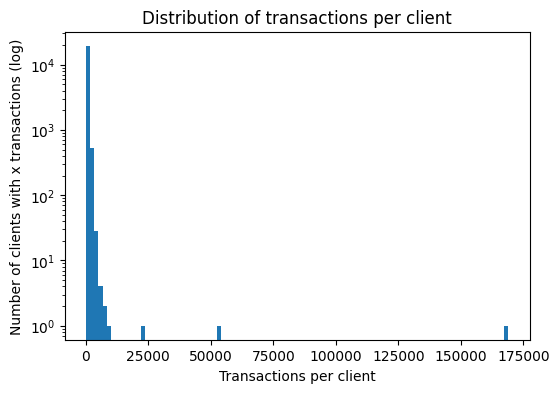

In [52]:
plt.figure(figsize=(6,4))
plt.hist(tx_per_client, bins=100)
plt.yscale("log")
plt.xlabel("Transactions per client")
plt.ylabel("Number of clients with x transactions (log)")
plt.title("Distribution of transactions per client")
plt.show()


### Теперь посмотрим сколько месяцев охватывает история клиента

In [65]:
months_per_client = (
    df.groupby("client_id")["year_month"]
    .nunique()
)

print("Количество охваченных месяцев уникальными клиентами")
print(months_per_client.describe())

print("\nПроцент клиентов с историей меньше x месяцев")
print(months_per_client.describe(percentiles=[0.1, 0.15, 0.2, 0.3, 0.4,0.5, 0.75, 0.9, 0.95, 0.99]))



Количество охваченных месяцев уникальными клиентами
count    20032.000000
mean        18.211711
std          7.792114
min          1.000000
25%         13.000000
50%         23.000000
75%         24.000000
max         25.000000
Name: year_month, dtype: float64

Процент клиентов с историей меньше x месяцев
count    20032.000000
mean        18.211711
std          7.792114
min          1.000000
10%          4.000000
15%          7.000000
20%         10.000000
30%         16.000000
40%         20.000000
50%         23.000000
75%         24.000000
90%         24.000000
95%         24.000000
99%         25.000000
max         25.000000
Name: year_month, dtype: float64


Оставим только тех клиентов, у которых история транзакций превышает K транзакций и охватываем m месяцев

# Посмотрим на уникальные хар-ки отправителя и получателя

In [75]:
src_cols = [
    "src_type11", "src_type12",
    "src_type21", "src_type22",
    "src_type31", "src_type32"
]

dst_cols = [
    "dst_type11", "dst_type12"
]

print("Посмотрим сколько уникальных значений принимает каждый категориальный признак")
for col in src_cols + dst_cols:
    print(f"""  Признак :{col}, уникальных значений: {df[col].nunique()}""")
    print("Топ 5 значений признака",df["src_type11"].value_counts(normalize=True).head(5),sep="\n")

Посмотрим сколько уникальных значений принимает каждый категориальный признак
  Признак :src_type11, уникальных значений: 47
Топ 5 значений признака
src_type11
22.0     0.756600
35.0     0.129982
134.0    0.036067
175.0    0.020666
102.0    0.020562
Name: proportion, dtype: float64
  Признак :src_type12, уникальных значений: 176
Топ 5 значений признака
src_type11
22.0     0.756600
35.0     0.129982
134.0    0.036067
175.0    0.020666
102.0    0.020562
Name: proportion, dtype: float64
  Признак :src_type21, уникальных значений: 3652
Топ 5 значений признака
src_type11
22.0     0.756600
35.0     0.129982
134.0    0.036067
175.0    0.020666
102.0    0.020562
Name: proportion, dtype: float64
  Признак :src_type22, уникальных значений: 84
Топ 5 значений признака
src_type11
22.0     0.756600
35.0     0.129982
134.0    0.036067
175.0    0.020666
102.0    0.020562
Name: proportion, dtype: float64
  Признак :src_type31, уникальных значений: 1181
Топ 5 значений признака
src_type11
22.0     0.7566

# Итак, подведём промежуточные итоги анализа
Нужно решить какие признаки будем использовать а также каких клиентов не будем рассматривать

## Фильтры клиентов

tx_count >= 20
history_months >= 6


## Числовые агрегаты

* tx_count
* mean / median / std суммы
* min / max
* p10 / p50 / p90
* monthly_tx_count_mean
* monthly_amount_mean


## Валюты

* n_unique_currency
* share_main_currency
* is_multicurrency


## Event type

* share_event_type_top1 … top10
* share_other_events
* n_unique_event_types


## Для каждого src/dst уровня

* n_unique
* top1_share
* top3_share



# Проанализируем распределение сумм транзакций(только в валюте 11)

In [ ]:
# Так как 99.9% транзакций происходят в валюте 11,
# и мы не можем корректно конвертировать другие валюты,
# оставляем только транзакции с currency == 11
df11 = df[df["currency"] == 11].copy()

In [97]:
print(f"Оставлено транзакций: {len(df11):,}")
print(f"Доля от всех транзакций: {len(df11) / len(df) * 100:.2f}%")


# Смотрим распределение и основные статистики
print("\nБазовые статистики по сумме транзакций")
display(
    df11["amount"].describe(
        percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

share_non_positive = (df11["amount"] <= 0).mean() * 100
print(f"Доля нулевых и отрицательных сумм: {share_non_positive:.3f}%")


Оставлено транзакций: 7,626,656
Доля от всех транзакций: 99.90%

Базовые статистики по сумме транзакций


count    7.626656e+06
mean     6.918292e+05
std      6.362286e+07
min      1.168688e-05
1%       6.172526e+00
5%       7.525784e+01
10%      2.751490e+02
25%      2.297181e+03
50%      1.665930e+04
75%      8.837422e+04
90%      3.742366e+05
95%      8.945112e+05
99%      4.907349e+06
max      8.811039e+10
Name: amount, dtype: float64

Доля нулевых и отрицательных сумм: 0.000%


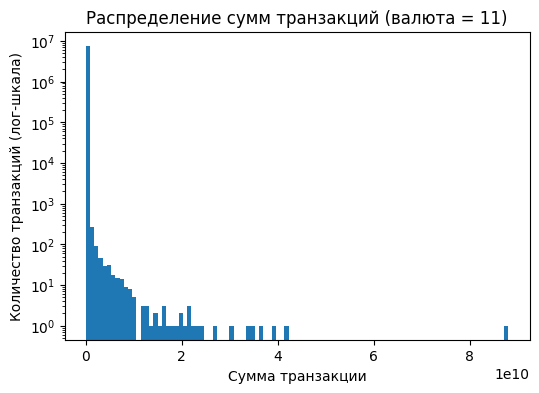

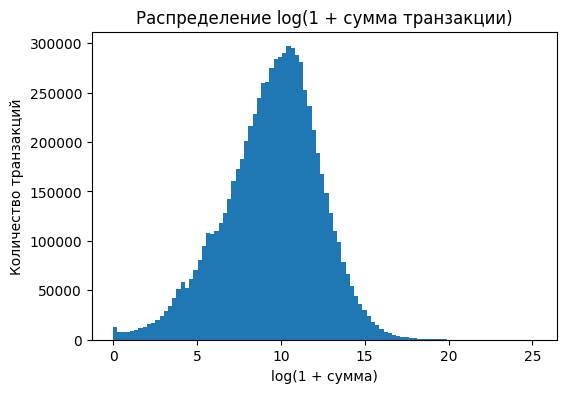

In [98]:
plt.figure(figsize=(6,4))
plt.hist(df11["amount"], bins=100)
plt.yscale("log")
plt.xlabel("Сумма транзакции")
plt.ylabel("Количество транзакций (лог-шкала)")
plt.title("Распределение сумм транзакций (валюта = 11)")
plt.show()

df11["log_amount"] = np.log1p(df11["amount"])

plt.figure(figsize=(6,4))
plt.hist(df11["log_amount"], bins=100)
plt.xlabel("log(1 + сумма)")
plt.ylabel("Количество транзакций")
plt.title("Распределение log(1 + сумма транзакции)")
plt.show()

### Базовые статистики показывают крайне асимметричное распределение с длинным правым хвостом:

медиана (50%) = 16 659

среднее значение = 691 829

стандартное отклонение = 63 622 860

максимальная сумма = 88 110 391 296


95% транзакций ≤ 895 тыс

Вывод:

1)  Для подавляющего большинства клиентов и транзакций характерны умеренные суммы, и именно они будут определять поведение массового сегмента.

2)  Среднее значение неинформативно и при анализе и создании признаков предпочтительнее использовать медианы, квантили, усечённые средние.

3)  Экстремальные значения экономически значимы,требуют либо отдельной модели, либо отдельного сегмента клиентов.

4)  Массовый и крупный сегменты следует разделять. Полученные распределения подтверждают целесообразность сегментации клиентов по масштабу активности,построения отдельных подходов для массовых и крупных клиентов.

In [100]:
# Анализ распределения сумм транзакций (валюта = 11)

amount_quantiles = (
    df11["amount"]
    .describe(percentiles=[0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
)

print("\nРаспределение сумм транзакций (валюта = 11)")
display(amount_quantiles.to_frame(name="amount"))

# Распределение транзакций по интервалам сумм
bins = [0, 10, 100, 1_000, 10_000, 100_000, 1_000_000, df11["amount"].max()]

amount_bins = pd.cut(df11["amount"], bins=bins)

amount_table = (
    amount_bins
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={
        "index": "Диапазон суммы",
        "count": "Количество транзакций"
    })
)

amount_table["Доля транзакций, %"] = (
    amount_table["Количество транзакций"]
    / amount_table["Количество транзакций"].sum()
    * 100
)

print("\nРаспределение сумм транзакций по диапазонам")
display(amount_table)



Распределение сумм транзакций (валюта = 11)


,amount
count,7.626656e+06
mean,6.918292e+05
std,6.362286e+07
min,1.168688e-05
0.1%,1.118445e-01
1%,6.172526e+00
5%,7.525784e+01
10%,2.751490e+02
25%,2.297181e+03
50%,1.665930e+04



Распределение сумм транзакций по диапазонам


,amount,Количество транзакций,"Доля транзакций, %"
0,"(0.0, 10.0]",102946,1.349818
1,"(10.0, 100.0]",338881,4.443376
2,"(100.0, 1000.0]",917396,12.028811
3,"(1000.0, 10000.0]",1894531,24.840913
4,"(10000.0, 100000.0]",2590080,33.960887
5,"(100000.0, 1000000.0]",1434924,18.814589
6,"(1000000.0, 88110391296.0]",347898,4.561606


Около 60% транзакций находятся в диапазоне 1 000–100 000, формируя основное поведение большинства клиентов. Крупные транзакции (>1 млн) составляют менее 5% операций, но оказывают существенное влияние на общий оборот, что делает их важными для моделирования. В связи с этим для дальнейшего анализа и построения моделей используется логарифмирование сумм транзакций, позволяющее стабилизировать распределение без потери информации о высокоактивных клиентах.

In [93]:
# Агрегации по клиенту
# Формируем поведенческие признаки на уровне клиента
amount_client = (
    df11
    .groupby("client_id")["amount"]
    .agg([
        "count",    # количество транзакций
        "sum",      # общая сумма транзакций
        "mean",     # средний чек
        "median",   # медианный чек
        "std",      # разброс сумм
        "min",
        "max"
    ])
)

# Добавляем квантили сумм
quantiles = (
    df11
    .groupby("client_id")["amount"]
    .quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    .unstack()
)
quantiles.columns = [f"квантиль_{int(q*100)}" for q in quantiles.columns]

amount_client = amount_client.join(quantiles)

print("\nПризнаки по суммам на уровне клиента (первые строки)")
display(amount_client.head())


Признаки по суммам на уровне клиента (первые строки)


,count,sum,mean,median,std,min,max,квантиль_10,квантиль_25,квантиль_50,квантиль_75,квантиль_90
client_id,,,,,,,,,,,,
00098f117ba54c5f21436d0687943b7140c356299f64cf0619488ddf081da260,10,468176.5,46817.648438,42665.289062,3.282159e+04,1968.406494,1.132841e+05,14315.348950,25504.527832,42665.289062,64035.036133,78020.396094
000afc90f17bbfcfe559432c975a1f7b65fd8c27ba222c854b4e416c225fc6c5,238,20211144.0,84920.773438,18535.420898,1.870062e+05,117.583565,1.133034e+06,2484.117676,6814.016602,18535.420898,48041.320312,207999.389063
000e047a31e50ba35f71c81962b4eb0b9a2d6080cf23a14f91447317dd14c788,388,19442290.0,50108.996094,31140.855469,6.170493e+04,0.197805,4.966886e+05,3787.264526,12895.494629,31140.855469,65370.993164,108026.938281
00112e0ce2b5d48c4e83ced4c0d01b8941c9f42177be815696931d3252ca25e3,86,7614606.0,88541.929688,36261.359375,1.171397e+05,2.279582,5.242258e+05,1708.060181,14462.803955,36261.359375,107604.373047,274557.453125
0011eb856025cc73656723ea7af19e335cdb2f005f2eac585c789ef141eb2d8e,432,238890672.0,552987.687500,97562.292969,2.939970e+06,4.316701,4.463590e+07,4227.662793,16895.192871,97562.292969,401967.203125,772067.700000


Квантили (10–90%) демонстрируют более стабильный профиль типичных операций и лучше отражают поведенческие паттерны клиента, чем среднее значение.
Наблюдается высокая гетерогенность клиентов по масштабу активности, что требует использования устойчивых статистик и, возможно, отдельной обработки крупных клиентов.

In [94]:
# Анализ выбросов
print("Распределение ключевых признаков по суммам")
display(
    amount_client[["sum", "mean", "max"]]
    .describe(percentiles=[0.9, 0.95, 0.99, 0.999])
)

# Ограничиваем экстремальные значения (клиппинг по 99 перцентилю)
# Это снижает влияние выбросов без удаления клиентов
for col in ["mean", "max", "квантиль_90"]:
    cap = amount_client[col].quantile(0.99)
    amount_client[col] = amount_client[col].clip(upper=cap)

# Доли маленьких и крупных транзакций
# Маленькие транзакции — ниже 25 перцентиля
# Крупные транзакции — выше 90 перцентиля
low_thr = df11["amount"].quantile(0.25)
high_thr = df11["amount"].quantile(0.9)

amount_client["доля_малых_транзакций"] = (
    (df11["amount"] < low_thr)
    .groupby(df11["client_id"])
    .mean()
)

amount_client["доля_крупных_транзакций"] = (
    (df11["amount"] > high_thr)
    .groupby(df11["client_id"])
    .mean()
)

Распределение ключевых признаков по суммам


,sum,mean,max
count,2.003200e+04,2.003200e+04,2.003200e+04
mean,2.633957e+08,5.626618e+05,3.117273e+07
std,6.076872e+09,1.047555e+07,8.798940e+08
min,4.474146e-02,4.474146e-02,4.474146e-02
50%,1.879472e+07,1.104148e+05,1.825792e+06
90%,2.561712e+08,6.194906e+05,2.159259e+07
95%,4.834130e+08,1.117578e+06,4.283006e+07
99%,1.849867e+09,4.790396e+06,2.061338e+08
99.9%,2.492583e+10,4.972146e+07,2.121775e+09
max,5.286727e+11,1.021144e+09,8.811039e+10


In [96]:
# Месячные агрегаты по суммам
# Эти признаки напрямую связаны с целевой переменной
df11["year_month"] = df11["event_time"].dt.to_period("M")

monthly_amount = (
    df11
    .groupby(["client_id", "year_month"])["amount"]
    .sum()
    .reset_index()
)

monthly_features = (
    monthly_amount
    .groupby("client_id")["amount"]
    .agg(
        средняя_месячная_сумма="mean",
        разброс_месячной_суммы="std",
        максимальная_месячная_сумма="max"
    )
)

amount_client = amount_client.join(monthly_features)

print("\nИтоговая таблица признаков по суммам")
display(amount_client.head())

print(f"\nИтого клиентов с рассчитанными признаками по суммам: {amount_client.shape[0]:,}")



Итоговая таблица признаков по суммам


,count,sum,mean,median,std,min,max,квантиль_10,квантиль_25,квантиль_50,квантиль_75,квантиль_90,доля_малых_транзакций,доля_крупных_транзакций,средняя_месячная_сумма,разброс_месячной_суммы,максимальная_месячная_сумма
client_id,,,,,,,,,,,,,,,,,
00098f117ba54c5f21436d0687943b7140c356299f64cf0619488ddf081da260,10,468176.5,46817.648438,42665.289062,3.282159e+04,1968.406494,1.132841e+05,14315.348950,25504.527832,42665.289062,64035.036133,78020.396094,0.100000,0.000000,6.688236e+04,4.615444e+04,1.256567e+05
000afc90f17bbfcfe559432c975a1f7b65fd8c27ba222c854b4e416c225fc6c5,238,20211144.0,84920.773438,18535.420898,1.870062e+05,117.583565,1.133034e+06,2484.117676,6814.016602,18535.420898,48041.320312,207999.389063,0.092437,0.071429,8.421310e+05,6.022841e+05,2.060616e+06
000e047a31e50ba35f71c81962b4eb0b9a2d6080cf23a14f91447317dd14c788,388,19442290.0,50108.996094,31140.855469,6.170493e+04,0.197805,4.966886e+05,3787.264526,12895.494629,31140.855469,65370.993164,108026.938281,0.077320,0.007732,8.100954e+05,4.813466e+05,2.239758e+06
00112e0ce2b5d48c4e83ced4c0d01b8941c9f42177be815696931d3252ca25e3,86,7614606.0,88541.929688,36261.359375,1.171397e+05,2.279582,5.242258e+05,1708.060181,14462.803955,36261.359375,107604.373047,274557.453125,0.127907,0.046512,3.626003e+05,4.349556e+05,1.353123e+06
0011eb856025cc73656723ea7af19e335cdb2f005f2eac585c789ef141eb2d8e,432,238890672.0,552987.687500,97562.292969,2.939970e+06,4.316701,4.463590e+07,4227.662793,16895.192871,97562.292969,401967.203125,772067.700000,0.060185,0.273148,1.327170e+07,1.625473e+07,5.239269e+07



Итого клиентов с рассчитанными признаками по суммам: 20,032


# Сформулируем примерно признаки, которые будем использовать на следующем этапе


**Фильтры клиентов:**

* `tx_count ≥ 20` — исключаем редких клиентов, для которых мало данных.
* `history_months ≥ 6` — учитываем только клиентов с достаточной историей, чтобы построить временные признаки.

**Числовые агрегаты по транзакциям:**

* `tx_count` — общее количество транзакций клиента.
* `sum_amount` — суммарная сумма всех транзакций, отражает общий оборот клиента.
* `mean_amount` — средняя сумма транзакции, показывает средний чек.
* `median_amount` — медианная сумма, устойчива к выбросам.
* `std_amount` — стандартное отклонение, отражает разброс сумм.
* `min_amount` / `max_amount` — минимальная и максимальная сумма транзакции.
* `quantile_10`, `quantile_25`, `quantile_50`, `quantile_75`, `quantile_90` — квантильные показатели распределения сумм транзакций.
* `share_small_transactions` — доля транзакций ниже 25% квантиля, помогает выявить «мелких» покупателей.
* `share_large_transactions` — доля транзакций выше 90% квантиля, показывает крупные сделки.
* `monthly_tx_count_mean` — среднее количество транзакций в месяц, показывает регулярность активности.
* `monthly_amount_mean`, `monthly_amount_std`, `monthly_amount_max` — средняя, стандартное отклонение и максимум сумм транзакций в месяц, отражают поведение во времени.

**Валюты:**

* `n_unique_currency` — число валют, в которых клиент совершал операции.
* `share_main_currency` — доля транзакций в основной валюте, показывает зависимость от одной валюты.
* `is_multicurrency` — бинарный признак: клиент работает с несколькими валютами или нет.

**Event type:**

* `n_unique_event_types` — количество различных типов транзакций, отражает разнообразие активности.
* `share_event_type_top1 … top10` — доля транзакций по самым частым типам, помогает выделить основные паттерны.
* `share_other_events` — доля транзакций остальных типов, учитывает редкие действия.

**Src/Dst категории (уровни 1,2,3):**

* `n_unique_src/dst_level` — число уникальных источников/получателей на уровне, отражает разнообразие контрагентов.
* `top1_share_src/dst_level` — доля транзакций по самому частому источнику/получателю.
* `top3_share_src/dst_level` — доля транзакций по трём наиболее частым источникам/получателям, учитывает ключевых партнёров.

**Лаговые признаки и rolling:**

* `amount_lag_1/3/6` — суммы транзакций клиента за предыдущие месяцы, вводят временную зависимость.
* `count_lag_1/3/6` — количество транзакций за предыдущие месяцы, показывает активность.
* `amount_roll_3m/6m` — скользящие средние сумм за 3 и 6 месяцев, выявляют тренды и сглаживают шум.
